# The Narrative Structure of the _Popol Wuj_:<br/>A Statistical Approach

Rafael C. Alvarado | Spring 2025

# Preliminaries

## Import code libraries

In [4806]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation as LDA
from sklearn.cluster import KMeans

In [4807]:
import sys; sys.path.append("../../local_lib/")

from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

## Set some hyperparameters

In [4808]:
px_template = 'plotly_white'

# Number of equal size chunks to divide the TOKEN table
n_chunks = 60

# Use if parsing strings of Mayan
# token_pattern = r"(?u)\b\w[\w']*\b"

# These are used with CounterVectorizer
min_ngram = 1
max_ngram = 1

# The limit below which words will be excluded from models
dh_thresh_agg = 'mean' # Use 'median' for much less severe cut

# Get and prepare the data

## Read in CHAP and TOKEN

In [4809]:
CHAP = pd.read_csv("christenson-CHAP-with-text.csv").set_index("chap_num")
TOKEN = pd.read_csv("christenson-TOKEN_QUC.csv").set_index(['chap_num','line_num','token_num']).dropna()

In [4810]:
# TOKEN[TOKEN.term_str.str.contains("'$", regex=True)]

## Create CHUNK

In [4811]:
TOKEN['chunk_id'] = (
    pd.DataFrame(np.array_split(TOKEN.index, n_chunks))
    .stack()
    .reset_index()
    .level_0
    .values + 1
)

In [4812]:
TOKEN.head(10)

token_str term_str  chunk_id
chap_num line_num token_num                             
1        1        0              ARE'     are'         1
                  1                 U        u         1
                  2               XE'      xe'         1
                  3              OJER     ojer         1
                  4             TZIJ,     tzij         1
         2        0             Waral    waral         1
                  1           K'iche'  k'iche'         1
                  2                 u        u         1
                  3             b'i'.     b'i'         1
         3        0             WARAL    waral         1

In [4813]:
CHUNK = (
    TOKEN
    .groupby('chunk_id')
    .term_str
    .count()
    .to_frame('n_tokens')
)

In [4814]:
CHUNK.value_counts('n_tokens')

n_tokens
489    41
488    19
Name: count, dtype: int64

In [4815]:
# CHUNK

## Create CHUNK CHAP Matrix

Chunk to Chapters Index

In [4816]:
CHUNK_CHAP_MATRIX = TOKEN.reset_index().value_counts(['chap_num', 'chunk_id']).unstack(fill_value=None)

In [4817]:
CHUNK_CHAP_MATRIX.sum(1).mean()

337.02298850574715

In [4818]:
CHUNK_CHAP_MATRIX.sum().value_counts()

489.0    41
488.0    19
Name: count, dtype: int64

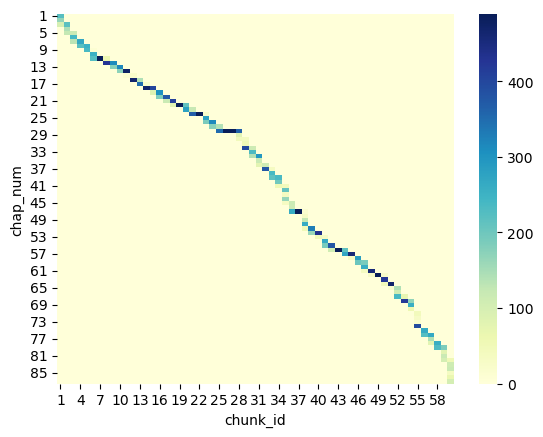

In [4819]:
sns.heatmap(CHUNK_CHAP_MATRIX.fillna(0), cmap='YlGnBu');

## Map CHAP to CHUNK

In [4820]:
CHUNK_TO_CHAP = (
    CHUNK_CHAP_MATRIX
    .apply(lambda x: x.dropna().index.tolist())
    .apply(pd.Series)
    .stack()
    .to_frame('chap_num')
    .join(CHAP.chap_title, on='chap_num')
)
CHUNK_TO_CHAP.index.names = ['chunk_id', 'chap_ord']
CHUNK_TO_CHAP['chap_label'] = CHUNK_TO_CHAP.chap_num.astype(int).astype(str) + ': ' + CHUNK_TO_CHAP.chap_title
CHUNK_TO_CHAP.chap_num = CHUNK_TO_CHAP.chap_num.astype(int)

In [4821]:
CHUNK_TO_CHAP

chap_num                                       chap_title  \
chunk_id chap_ord                                                              
1        0                1                                         Preamble   
         1                2                             The Primordial World   
         2                3                        The Creation of the Earth   
2        0                3                        The Creation of the Earth   
         1                4                      The Creation of the Animals   
...                     ...                                              ...   
60       1               83                      The Dynasty of Nihaib Lords   
         2               84             The Great Houses of the Nihaib Lords   
         3               85                 The Dynasty of Ahau Quiché Lords   
         4               86        The Great Houses of the Ahau Quiché Lords   
         5               87  The Three Great Stewards as Mothers of the Word   

                                                          chap_label  
chunk_id chap_ord                                                     
1        0                                               1: Preamble  
         1                                   2: The Primordial World  
         2                              3: The Creation of the Earth  
2        0                              3: The Creation of the Earth  
         1                            4: The Creation of the Animals  
...                                                              ...  
60       1                           83: The Dynasty of Nihaib Lords  
         2                  84: The Great Houses of the Nihaib Lords  
         3                      85: The Dynasty of Ahau Quiché Lords  
         4             86: The Great Houses of the Ahau Quiché Lords  
         5         87: The Three Great Stewards as Mothers of the...  

[145 rows x 3 columns]

Chapter Labels for Chunks

In [4822]:
CHUNK['short_label'] = CHUNK_TO_CHAP.groupby('chunk_id').chap_num.apply(lambda x: '[' + str(x.name) + '] ' + ' '.join(map(str,x)))
CHUNK['long_label'] = CHUNK_TO_CHAP.groupby('chunk_id').chap_label.apply(lambda x: '[' + str(x.name) + '] ' + ' '.join(map(str, x)))

In [4823]:
CHUNK.head()

,n_tokens,short_label,long_label
chunk_id,,,
1,489,[1] 1 2 3,[1] 1: Preamble 2: The Primordial World 3: The...
2,489,[2] 3 4 5,[2] 3: The Creation of the Earth 4: The Creati...
3,489,[3] 5 6 7,[3] 5: The Fall of the Animals 6: The Creation...
4,489,[4] 7 8,[4] 7: The Creation of the Effigies of Carved ...
5,489,[5] 8 9,[5] 8: The Fall of the Effigies of Carved Wood...


## Map CHUNK to CHAP

In [4824]:
CHAP['chunk_ids'] = CHUNK_CHAP_MATRIX.stack().reset_index().groupby('chap_num').chunk_id.apply(lambda x: ','.join(map(str, x)))

In [4825]:
CHAP.head()

,chap_title,page_num,xom_start,xom_end,xom_start_fixed,xom_end_fixed,n_lines,chap_eng_str,chap_quc_str,chunk_ids
chap_num,,,,,,,,,,
1,Preamble,59,1,96,1,96,96,"THIS ITS ROOT ANCIENT WORD, Here Quiché its na...","ARE' U XE' OJER TZIJ, Waral K'iche' u b'i'. WA...",1
2,The Primordial World,67,97,154,97,154,58,THIS ITS ACCOUNT These things. Still be it sil...,"ARE' U TZIJOXIK Wa'e. K'a katz'ininoq, K'a kac...",1
3,The Creation of the Earth,70,155,274,155,274,120,"THEN came therefore his word here, He arrived ...","TA xpe k'ut u tzij waral, Xul kuk' Ri Tepew, Q...","1,2"
4,The Creation of the Animals,74,275,339,275,339,65,THEN they conceived again Its animals mountain...,"TA xkino'jij chik U chikopil juyub', Chajal re...",2
5,The Fall of the Animals,76,340,433,340,433,94,"THEN it was said to again therefore the deer, ...","TA xe'uchax chi k'ut ri kiej, Tz'ikin Rumal Tz...","2,3"


# Craate vector spaces

## Create BOW for CHAP and CHUNK

In [4826]:
BOW_CHAP = TOKEN.groupby(['chap_num', 'term_str']).term_str.count()
BOW_CHUNK = TOKEN.groupby(['chunk_id', 'term_str']).term_str.count()

## Create CTM

In [4827]:
CTM = BOW_CHUNK.unstack(fill_value=0)

In [4828]:
CTM.sample(10).T.sample(10).T.style.background_gradient(axis=None, cmap='Blues')

term_str,katwar,pix,julujuj,tamasul,ketal,kib'och'il,chiwila',xkichap,xesaqir,qan
chunk_id,,,,,,,,,,
35,0,0,0,0,0,0,1,0,0,0
31,0,0,0,0,0,0,1,0,0,0
52,0,0,0,0,0,0,0,0,0,0
53,0,0,0,0,0,0,0,0,0,0
56,0,0,0,0,0,0,0,0,0,0
39,0,0,0,0,0,0,0,0,0,0
36,0,0,0,0,0,0,0,0,0,0
38,0,0,0,0,0,0,0,0,0,0
28,0,0,0,0,0,0,1,1,0,0


# Vocabulary

## Extract VOCAB from CTM

In [4829]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)

In [4830]:
VOCAB

,n,grams
term_str,,
a,23,1
a',12,1
a'on,2,1
ab'aj,31,1
ab'ajil,1,1
...,...,...
yoq'otajinaq,1,1
yujuj,2,1
yuq,1,1


## Compute DFIDF

In [4831]:
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / n_chunks
VOCAB['dh'] = VOCAB.dp * np.log2(1/VOCAB.dp)

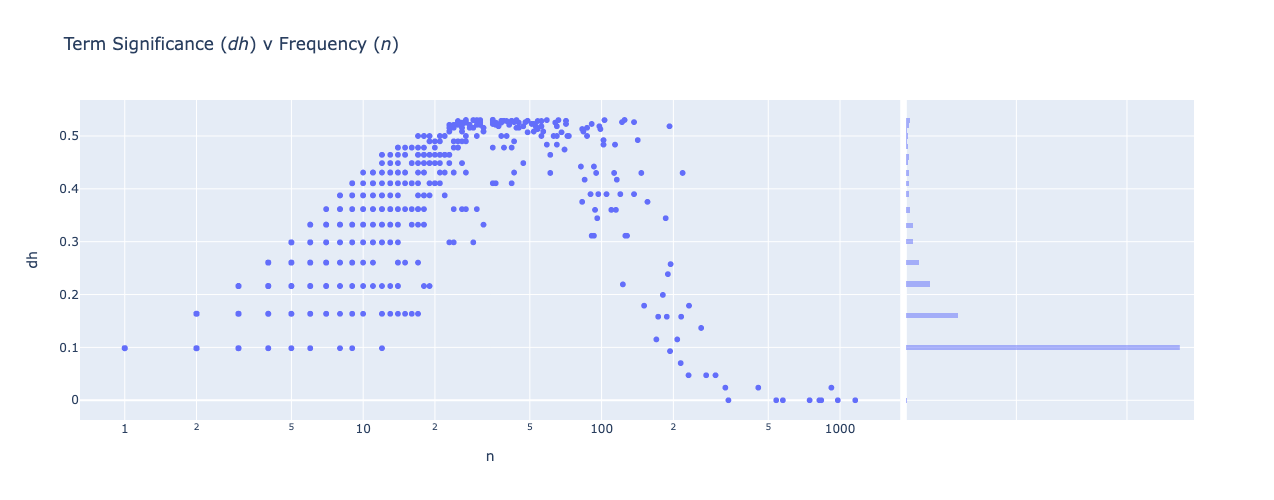

In [4832]:
px.scatter(VOCAB.reset_index(), 'n', 'dh', 
           log_x=True, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
          title="Term Significance (<i>dh</i>) v Frequency (<i>n</i>)")

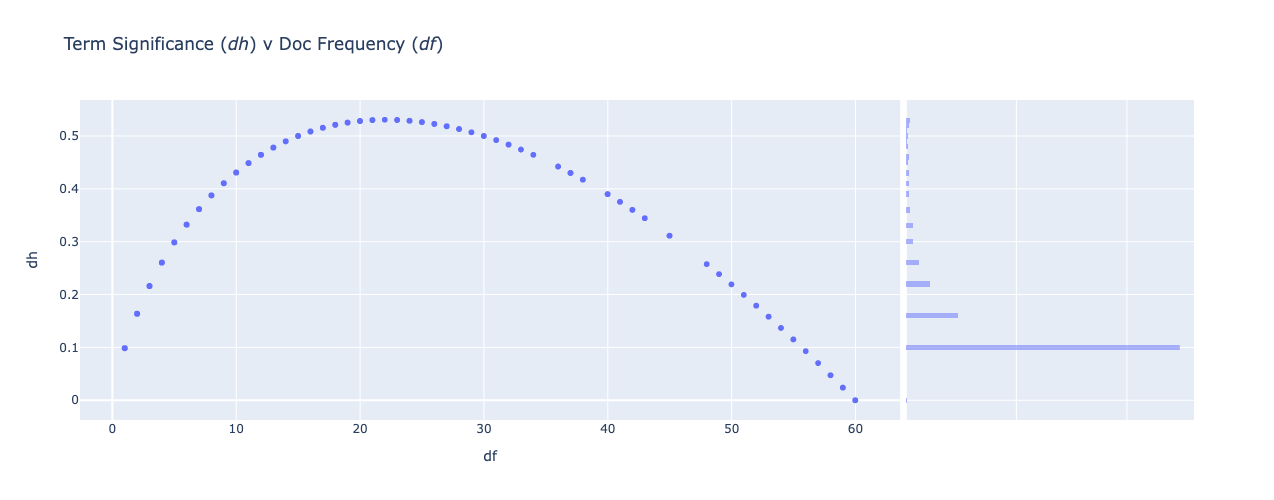

In [4833]:
px.scatter(VOCAB.reset_index(), 'df', 'dh', 
           log_x=False, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
          title="Term Significance (<i>dh</i>) v Doc Frequency (<i>df</i>)")

In [4834]:
VOCAB.describe()

,n,grams,df,dp,dh
count,3767.000000,3767.0,3767.000000,3767.000000,3767.000000
mean,7.783647,1.0,3.197239,0.053287,0.156108
std,44.613965,0.0,6.828925,0.113815,0.106787
min,1.000000,1.0,1.000000,0.016667,0.000000
25%,1.000000,1.0,1.000000,0.016667,0.098448
50%,1.000000,1.0,1.000000,0.016667,0.098448
75%,3.000000,1.0,2.000000,0.033333,0.163563
max,1161.000000,1.0,60.000000,1.000000,0.530735


## Define Significant Terms

In [4835]:
max_entropy = VOCAB.dh.agg(dh_thresh_agg)

In [4836]:
dh_thresh_agg, max_entropy

('mean', 0.15610788313935567)

In [4837]:
VOCAB['sig'] = VOCAB.dh >= max_entropy

In [4838]:
VOCAB[VOCAB.sig == True].sample(10, weights='dh')

,n,grams,df,dp,dh,sig
term_str,,,,,,
xe'ok,17,1,11,0.183333,0.448701,True
xkaj,10,1,8,0.133333,0.387585,True
chikib'ano,15,1,9,0.150000,0.410545,True
ruk',93,1,36,0.600000,0.442179,True
chinamit,19,1,9,0.150000,0.410545,True
apanoq,14,1,13,0.216667,0.478064,True
xkitaq,9,1,6,0.100000,0.332193,True
tz'um,5,1,5,0.083333,0.298747,True
xek'ulun,3,1,2,0.033333,0.163563,True


In [4839]:
'Number of significant terms', VOCAB[VOCAB.sig].shape[0]

('Number of significant terms', 1272)

In [4840]:
'Number of rejected words', len(VOCAB[~VOCAB.sig]) 

('Number of rejected words', 2495)

In [4841]:
'Percent VOCAB used', round((len(VOCAB[VOCAB.sig]) / len(VOCAB)), 2) * 100

('Percent VOCAB used', 34.0)

## Provide gloss feature

In [4842]:
VOCAB['gloss'] = None

# Term Significance

## Compute TFIDF over non-stopwords

We weight the significance of words in each chunk using TFIDF.

TFIDF is an established method for estimating the significance of a word in a context by weighing its local frequency in a context against its global frequency in the corpus.

- To the degree that a word is frequent in a specific context and the general corpus, it is not considered siginficant.
- To the degree that a word is frequent in a specific context and infrequenct in the general corpus, it is considered significant.

In [4843]:
CTMX = CTM[VOCAB[VOCAB.sig].index]

In [4844]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    

In [4845]:
# TFIDF.sample(10).sort_index().T.sample(5).sort_index().T.style.background_gradient(axis=None, cmap='YlGnBu')

# Hierarchical Clusters

## Cluster CHUNK docs by TFIDF
We generate a square matrix of documents by documents showing pairwise similarities.

In [4846]:
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index, columns=TFIDF.index)

In [4847]:
tfidf_hac = HAC(TFIDF_SIM, labels=CHUNK['short_label'].to_list())

In [4848]:
tfidf_hac.get_sims()
tfidf_hac.get_tree()

In [4849]:
TREE = pd.DataFrame(tfidf_hac.TREE, columns=['i','j','d','n'])

## Choose cluster cut-off

Play with threshold.\
Each cut-off highlights different parts.

<Figure size 640x480 with 0 Axes>

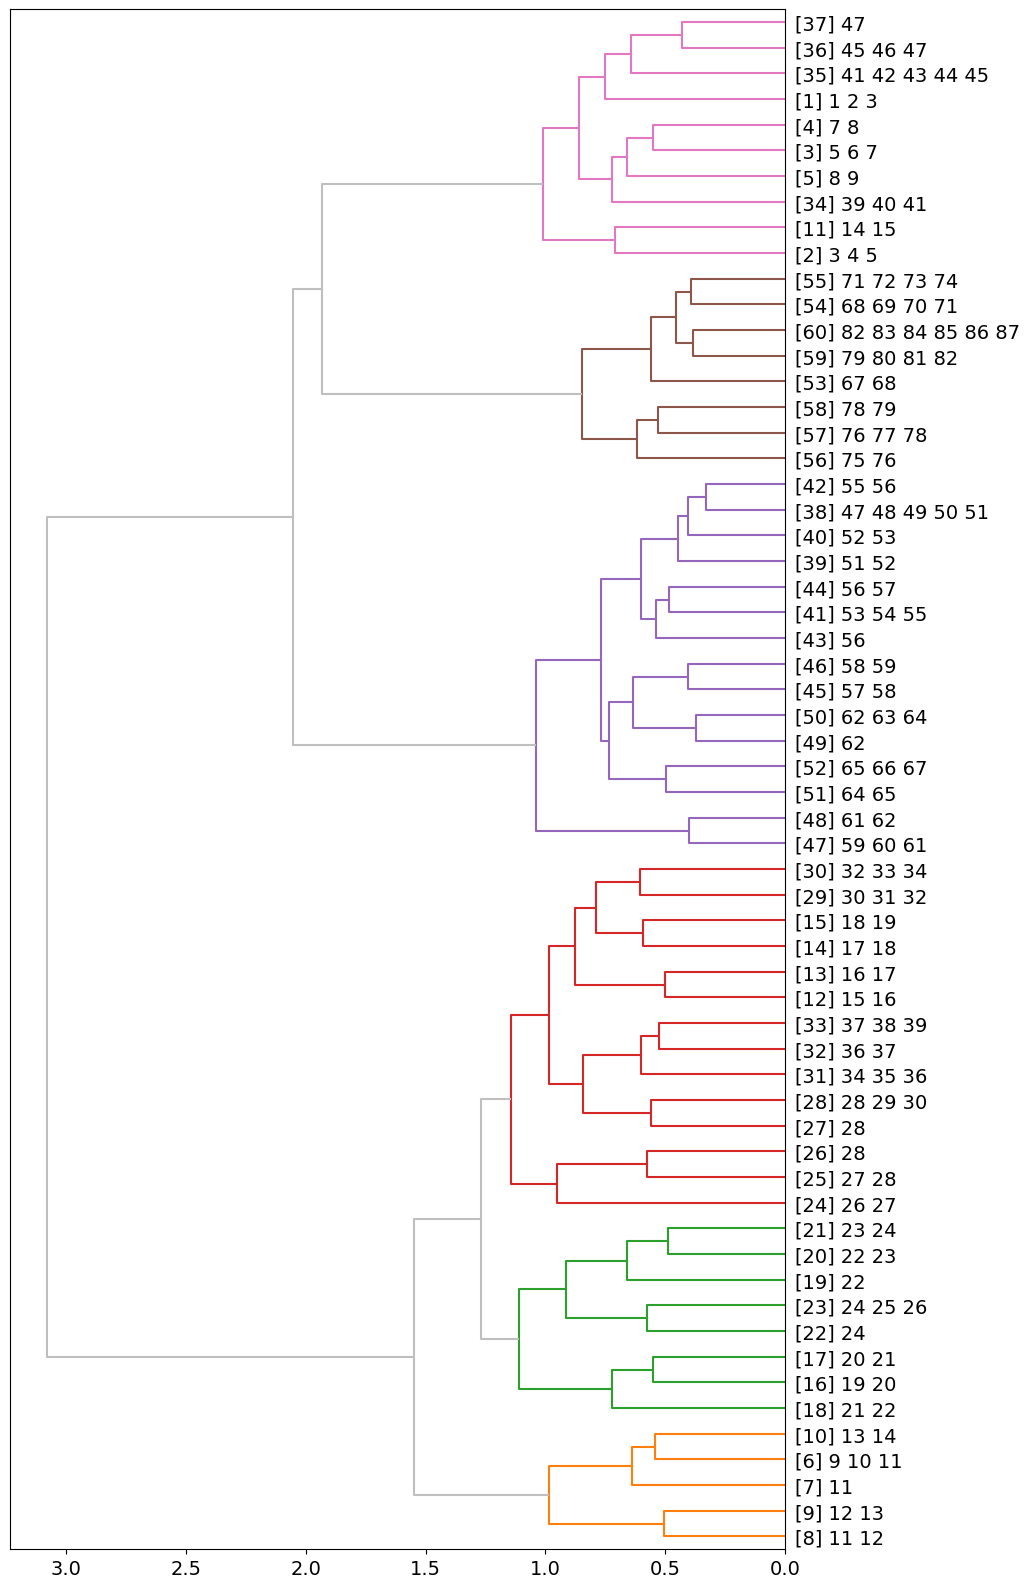

In [4850]:
tfidf_hac.color_thresh = 1.2
tfidf_hac.plot_tree()

## View heatmap of document clusters

A heatmap of the same space provides some insight into the nature of the clusters.

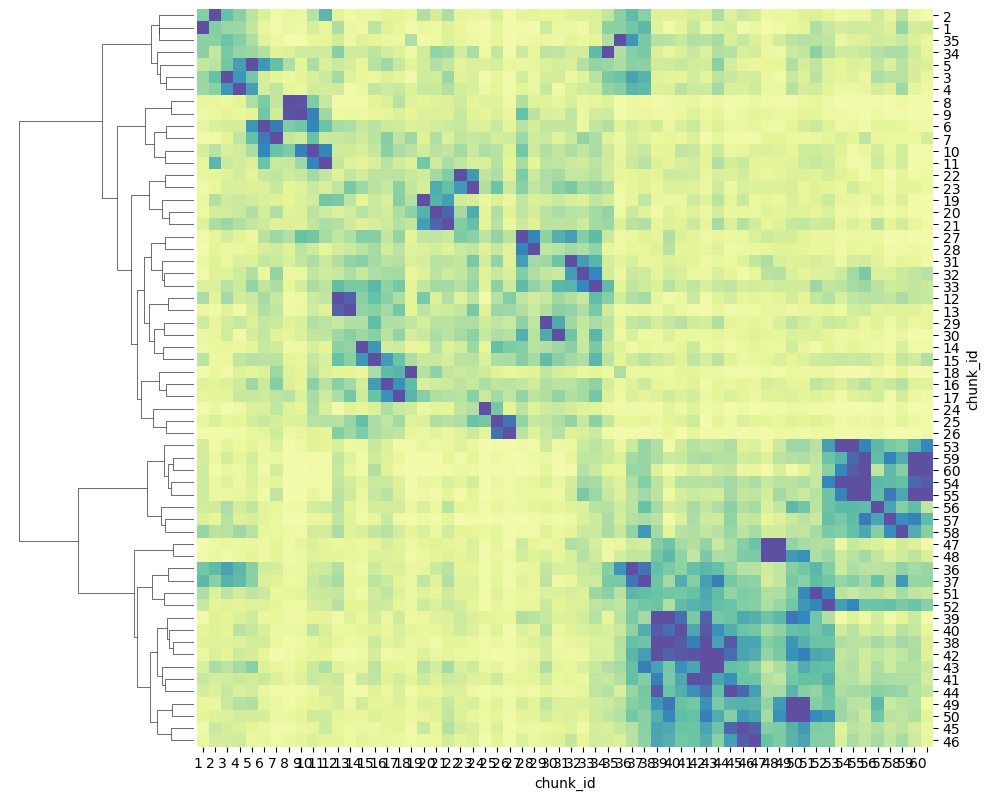

In [4851]:
fig = sns.clustermap(TFIDF_SIM,
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True)
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

**Interpretation**

- Two main groups.
- Visual inspection shows this corresponds to the first and second halves of the book consistent with how the text is divided by all editions.
- The exception is the group containing chs 1-8 and 39-46 -- this group reflects the theme of creation, which begins both the first and second halves.
- This "echo" marks are thematic touch point.

## Apply cluseter labels to chunks

In [4852]:
tfidf_hac.get_cluster_labels()

In [4853]:
CHUNK['cluster_label'] = tfidf_hac.CLUSTER_LABELS

In [4854]:
try:
    TOKEN = TOKEN.join(CHUNK.cluster_label, on="chunk_id")
except:
    pass

## Label chapters with clusters

In [4855]:
CHAP['cluster_label'] = (
    TOKEN
    .reset_index()
    .value_counts(['chap_num','cluster_label'])
    .unstack(fill_value=0)
    .idxmax(1)
)

## Create CLUSTER

In [4856]:
CLUSTER_CHUNK = TOKEN.groupby(['cluster_label','chunk_id']).chunk_id.count().unstack(fill_value=0).astype(bool).astype(int)

In [4857]:
# px.imshow(CLUSTER_CHUNK, color_continuous_scale=px.colors.diverging.Spectral, color_continuous_midpoint=0)

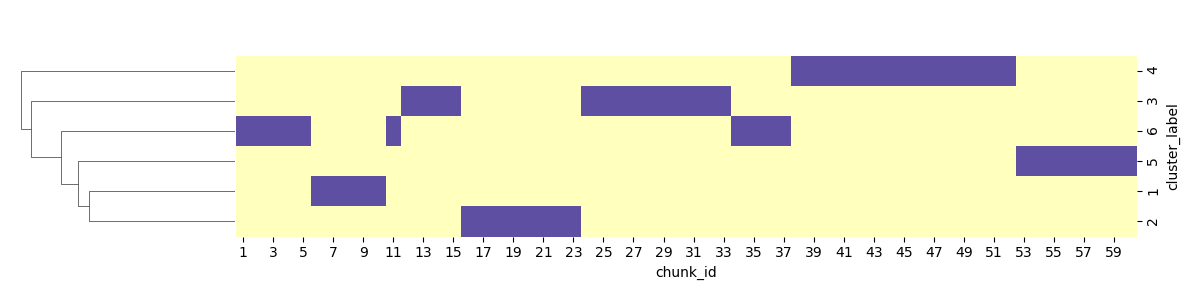

In [4858]:
sns.clustermap(CLUSTER_CHUNK, 
                    cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12,3))

In [4859]:
# CLUSTER_CHUNK

In [4860]:
CLUSTER = CHUNK.cluster_label.value_counts().to_frame('n_chunks')

In [4861]:
CLUSTER

,n_chunks
cluster_label,
4,15
3,14
6,10
2,8
5,8
1,5


## Add order to CLUSTER

In [4862]:
labels = {}
ord = 0
for lbl in CHUNK.sort_index().cluster_label.values:
    if lbl not in labels:
        ord += 1
        labels[lbl] = ord

In [4863]:
CLUSTER['ord'] = pd.Series(labels)

In [4864]:
CLUSTER.sort_values('ord')

,n_chunks,ord
cluster_label,,
6,10,1
1,5,2
3,14,3
2,8,4
4,15,5
5,8,6


## Create CLUSTER_TFIDF model

**Cluster label glosses**

We find significant words for each cluster based on mean TFIDF grouping by cluster.

This also creates a model from the labels; that is, each cluster label is associated with a distribution over words.

In [4865]:
label_col = "cluster_label"
CLUSTER_TFIDF = (
    TFIDF
    .join(CHUNK[label_col])
    .groupby(label_col)
    .mean()
)

In [4866]:
CLUSTER_TFIDF.T.sample(5).sort_index().T.style.background_gradient(axis=None)

,chok,junoq,kakina'o,kar,xkitzij
cluster_label,,,,,
1,0.007780,0.000000,0.000000,0.017854,0.000000
2,0.000000,0.013171,0.000000,0.000000,0.000000
3,0.006296,0.002429,0.008086,0.004359,0.006148
4,0.002739,0.000000,0.000000,0.000000,0.000000
5,0.022488,0.000000,0.000000,0.000000,0.000000
6,0.004566,0.000000,0.000000,0.004941,0.000000


In [4867]:
VOCAB['max_cluster'] = CLUSTER_TFIDF.idxmax()

In [4868]:
CLUSTER['gloss'] = CLUSTER_TFIDF.idxmax(1)
CLUSTER['top_terms'] = CLUSTER_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [4869]:
CLUSTER

,n_chunks,ord,gloss,top_terms
cluster_label,,,,
4,15,5,b'alam,"b'alam, amaq', tojil, kitze, b'i', majukutaj, ..."
3,14,3,xib'alb'a,"xib'alb'a, kame, junajpu, wuqub', xcha', kik',..."
6,10,1,kaj,"kaj, b'it, aj, winaq, ulew, tz'aq, tz'ikin"
2,8,4,q'apoj,"q'apoj, kati't, ati't, che', chowen, ch'o, b'atz'"
5,8,6,ajaw,"ajaw, ajawab', ja, aj, pop, nim, tinamit"
1,5,2,sipakna,"sipakna, kaqix, k'ajolab', wuqub', jul, o', much'"


## Assign glosses by hand

In [4870]:
VOCAB[VOCAB.dh > VOCAB.dh.quantile(.9)].sort_values('dh', ascending=False).head(10)

,n,grams,df,dp,dh,sig,gloss,max_cluster
term_str,,,,,,,,
tzatz,35,1,22,0.366667,0.530735,True,None,4.0
su,27,1,23,0.383333,0.530276,True,None,2.0
chikiwach,35,1,23,0.383333,0.530276,True,None,2.0
amaq',125,1,23,0.383333,0.530276,True,None,4.0
at,59,1,21,0.350000,0.530101,True,None,6.0
waral,30,1,21,0.350000,0.530101,True,None,6.0
wa'e,29,1,21,0.350000,0.530101,True,None,5.0
xib'alb'a,103,1,21,0.350000,0.530101,True,None,3.0
k'ab'awil,66,1,21,0.350000,0.530101,True,None,4.0


In [4871]:
glosses = {
    "b'alam": "jaguar",
    "ajaw": "lord",
    "kaj": "sky",
    "xib'alb'a": "underworld (earth)",
    "q'apoj": "maiden, virgin",
    "sipakna": "Zipacna",
    "kati't": "grandmother",
    "kaqix": "macaw",
    "tojil": "Tojil",
    "kame": "death",
    "pop": "mat",
    "q'alel": "magistrate",
    "b'it": "shap(er)",
    "ch'o": "rat",
    "qati't": "grandmother",
    "le'": "generation",
    "amaq'": "nations",
    "k'ajolab'": "boys",
    "alom": "children",
    "chowen": "artisan"
}

for key, val in glosses.items():
    VOCAB.loc[key, 'gloss'] = val

In [4872]:
VOCAB[~VOCAB.gloss.isna()]

,n,grams,df,dp,dh,sig,gloss,max_cluster
term_str,,,,,,,,
ajaw,137,1,25,0.416667,0.526264,True,lord,5.0
alom,17,1,7,0.116667,0.361612,True,children,6.0
amaq',125,1,23,0.383333,0.530276,True,nations,4.0
b'alam,193,1,27,0.450000,0.518401,True,jaguar,4.0
b'it,35,1,9,0.150000,0.410545,True,shap(er),6.0
ch'o,14,1,2,0.033333,0.163563,True,rat,2.0
chowen,27,1,7,0.116667,0.361612,True,artisan,2.0
k'ajolab',87,1,17,0.283333,0.515505,True,boys,1.0
kaj,91,1,26,0.433333,0.522795,True,sky,6.0


## Apply CLUSTER_TFIDF model to TOKEN

**Group by CHUNK**

In [4873]:
CHUNK['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chunk_id')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHUNK['max_cluster_gloss'] = CHUNK.max_cluster.map(CLUSTER.gloss)

In [4874]:
CHUNK[['long_label', 'cluster_label', 'max_cluster','max_cluster_gloss']].style.background_gradient(cmap="YlGnBu")

,long_label,cluster_label,max_cluster,max_cluster_gloss
chunk_id,,,,
1,[1] 1: Preamble 2: The Primordial World 3: The Creation of the Earth,6,6,kaj
2,[2] 3: The Creation of the Earth 4: The Creation of the Animals 5: The Fall of the Animals,6,6,kaj
3,[3] 5: The Fall of the Animals 6: The Creation of the Mud Person 7: The Creation of the Effigies of Carved Wood,6,6,kaj
4,[4] 7: The Creation of the Effigies of Carved Wood 8: The Fall of the Effigies of Carved Wood,6,6,kaj
5,[5] 8: The Fall of the Effigies of Carved Wood 9: The Pride of Seven Macaw Before the Dawn,6,6,kaj
6,[6] 9: The Pride of Seven Macaw Before the Dawn 10: The Fall of Seven Macaw and His Sons 11: The Defeat of Seven Macaw,1,1,sipakna
7,[7] 11: The Defeat of Seven Macaw,1,1,sipakna
8,[8] 11: The Defeat of Seven Macaw 12: The Deeds of Zipacna and the Four Hundred Boys,1,1,sipakna
9,[9] 12: The Deeds of Zipacna and the Four Hundred Boys 13: The Defeat of Zipacna,1,1,sipakna


No difference. 

**Group by CHAP**

In [4875]:
CHAP['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chap_num')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHAP['max_cluster_gloss'] = CHAP.max_cluster.map(CLUSTER.gloss)

In [4876]:
CHAP[['chap_title', 'cluster_label', 'max_cluster', 'max_cluster_gloss']].style.background_gradient(cmap="YlGnBu")

,chap_title,cluster_label,max_cluster,max_cluster_gloss
chap_num,,,,
1,Preamble,6,6,kaj
2,The Primordial World,6,6,kaj
3,The Creation of the Earth,6,6,kaj
4,The Creation of the Animals,6,6,kaj
5,The Fall of the Animals,6,6,kaj
6,The Creation of the Mud Person,6,6,kaj
7,The Creation of the Effigies of Carved Wood,6,6,kaj
8,The Fall of the Effigies of Carved Wood,6,6,kaj
9,The Pride of Seven Macaw Before the Dawn,6,6,kaj


# Principal Components

## Apply PCA to TFIDF

PCA sheds light on the relationship between the clusters.

We add $1$ to $k$ if odd to ensure we have pairs to display.

In [4877]:
X = TFIDF

In [4878]:
n_comps = 5
pca_engine = PCA(n_components=5)
PCAX = pd.DataFrame(pca_engine.fit_transform(X), index=X.index)
PCAX.index.name = 'chunk_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = X.columns)
LOADINGS.index.name = 'term_str'

In [4879]:
# PCAX

## Visualize compontents and clusters

In [4880]:
# CHUNK

In [4881]:
X0 = CHUNK.join(PCAX)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.max_cluster_gloss,
        # symbol=X0.max_topic,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        template=px_template,
        height=850, width=950).show()
    

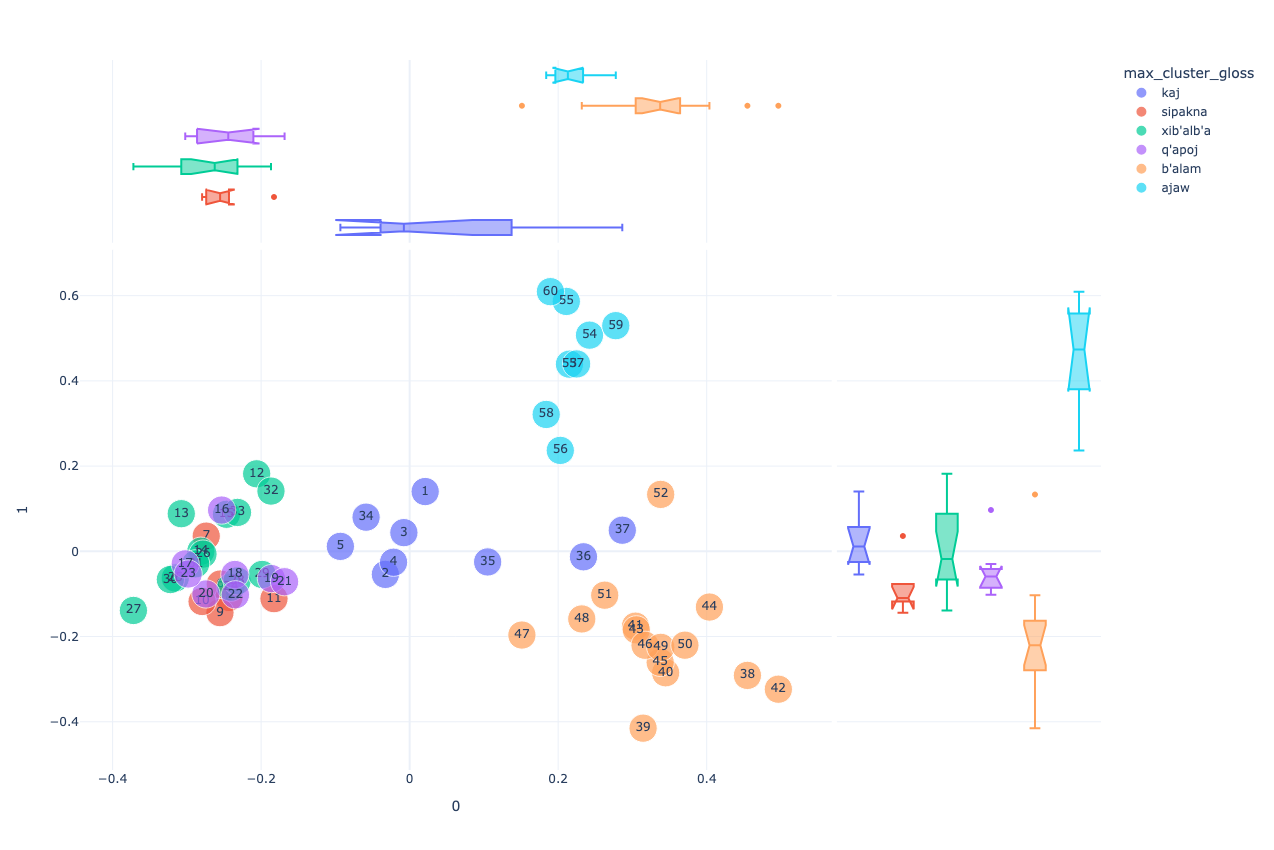

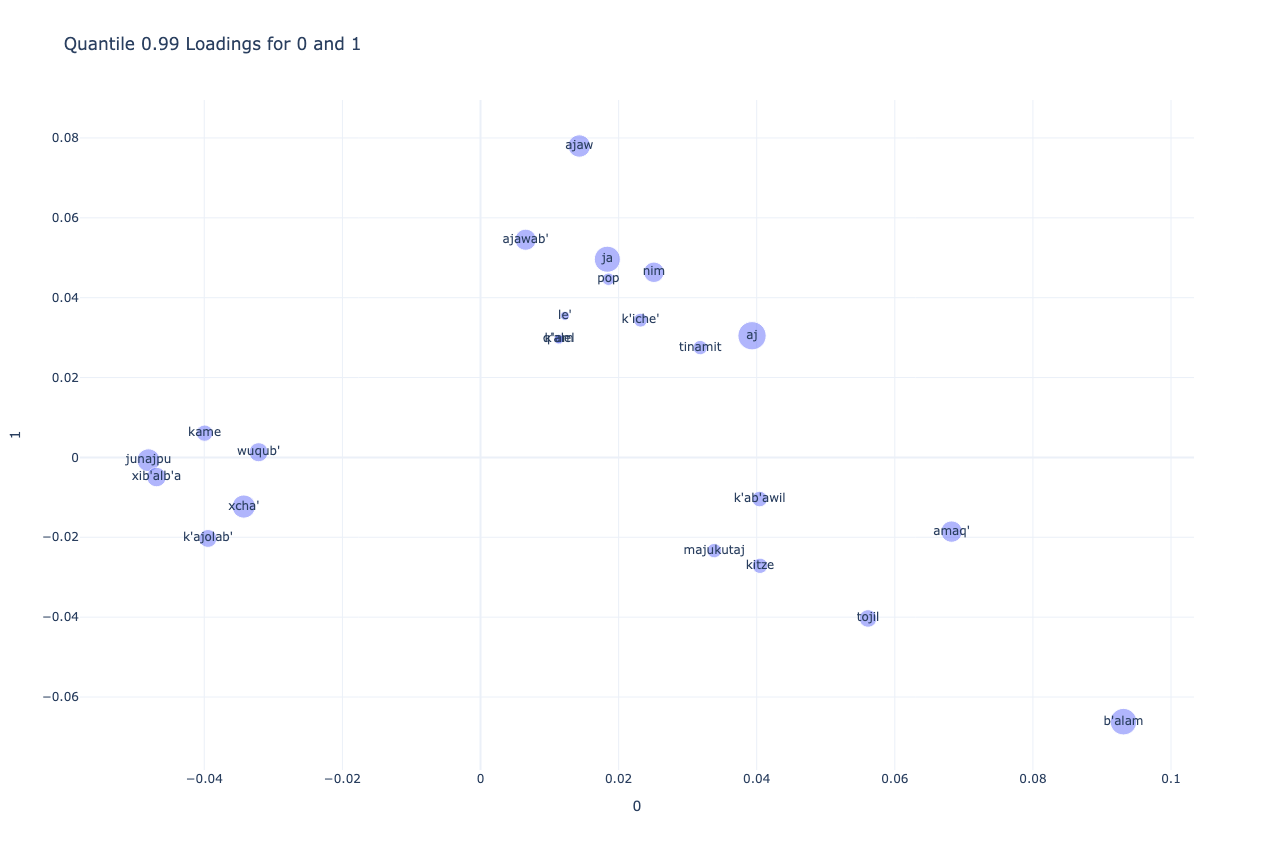

In [4882]:
plot_pca(0,1)

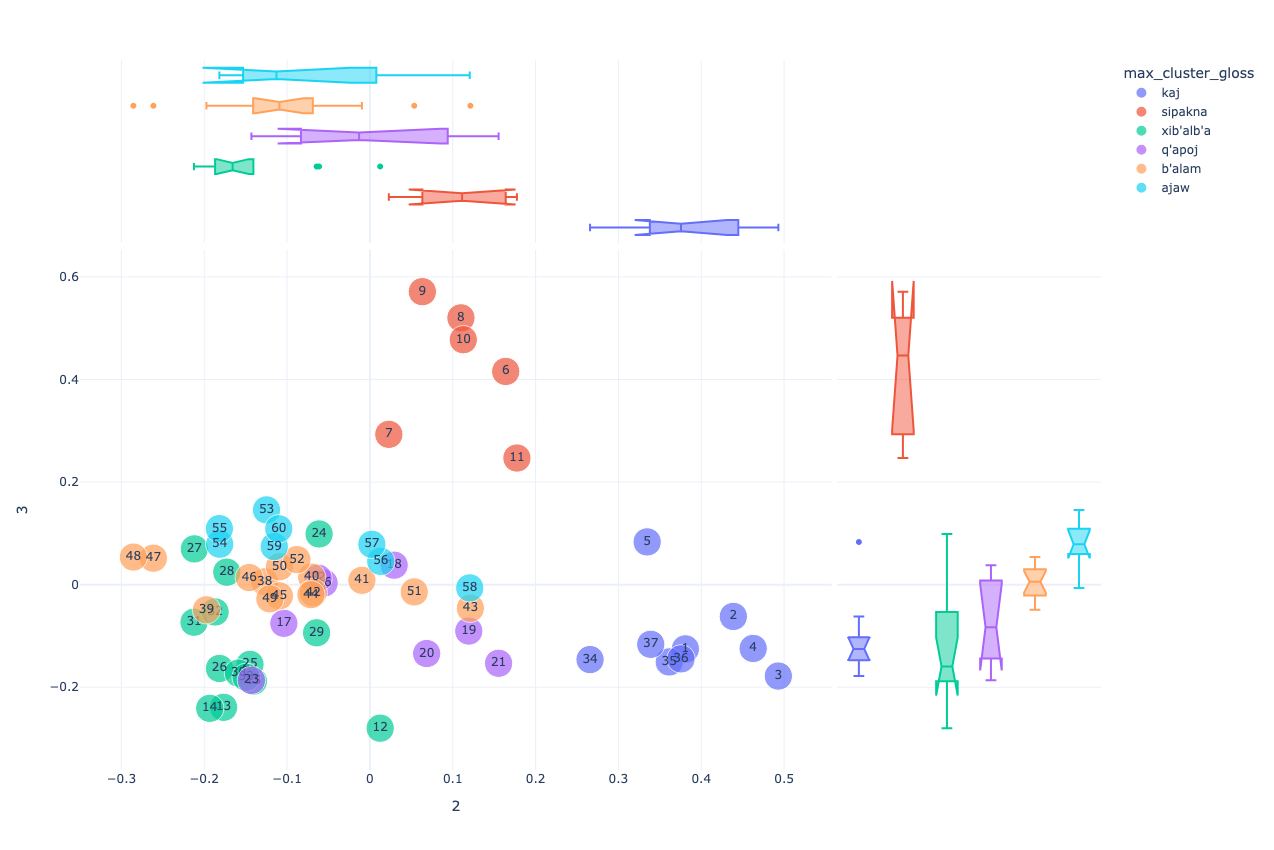

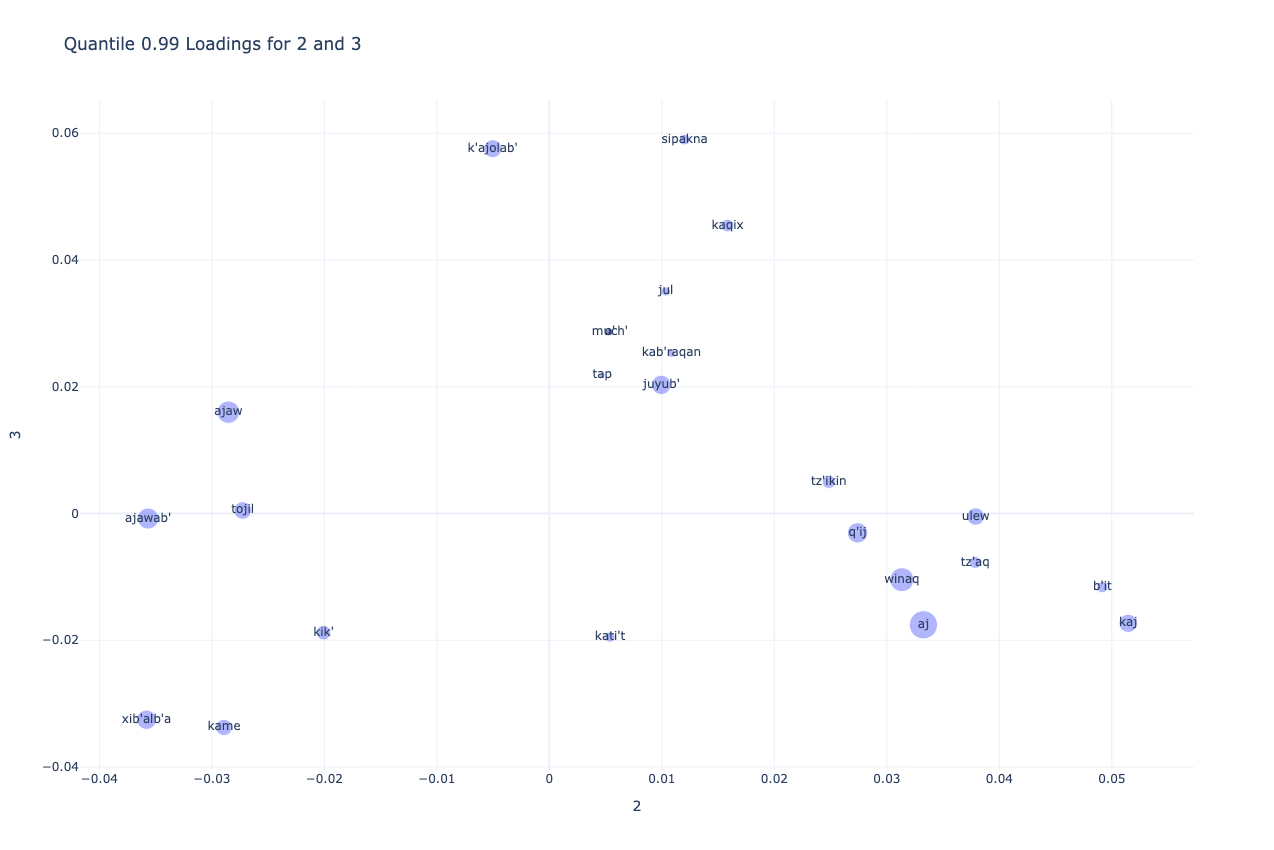

In [4883]:
plot_pca(2,3)

## Component Histograms

In [4884]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='max_cluster_gloss',
           color='max_cluster_gloss', 
           template=px_template,
           # height=400, width=600, 
           title=f'PC {i}').show()

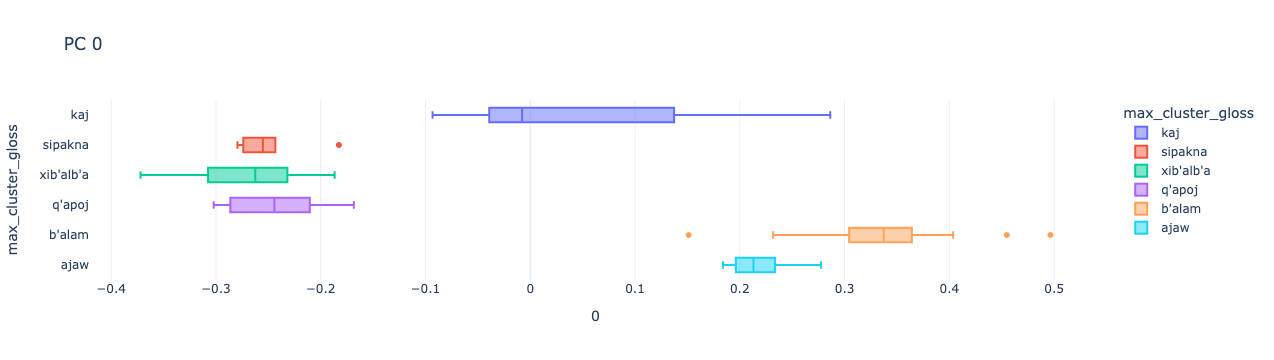

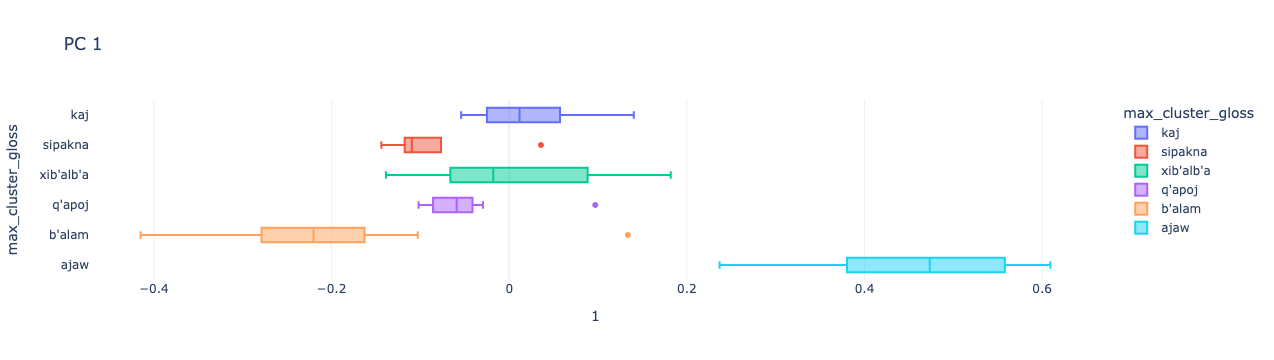

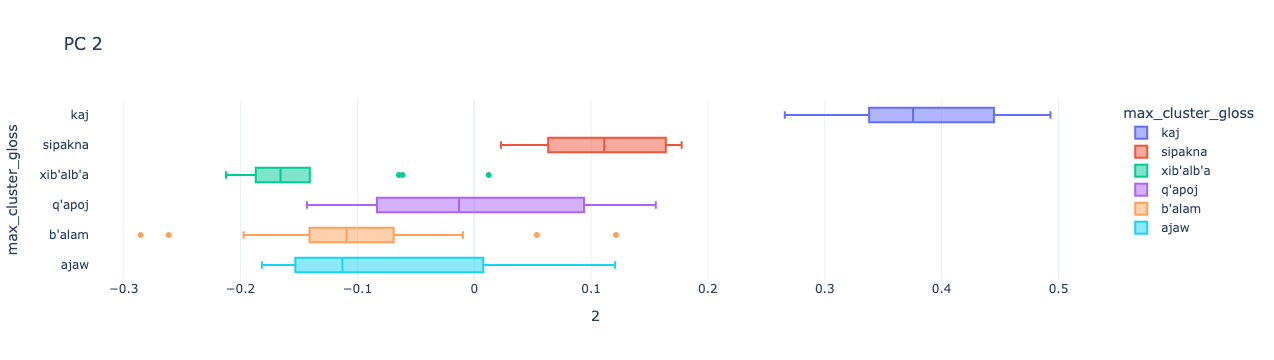

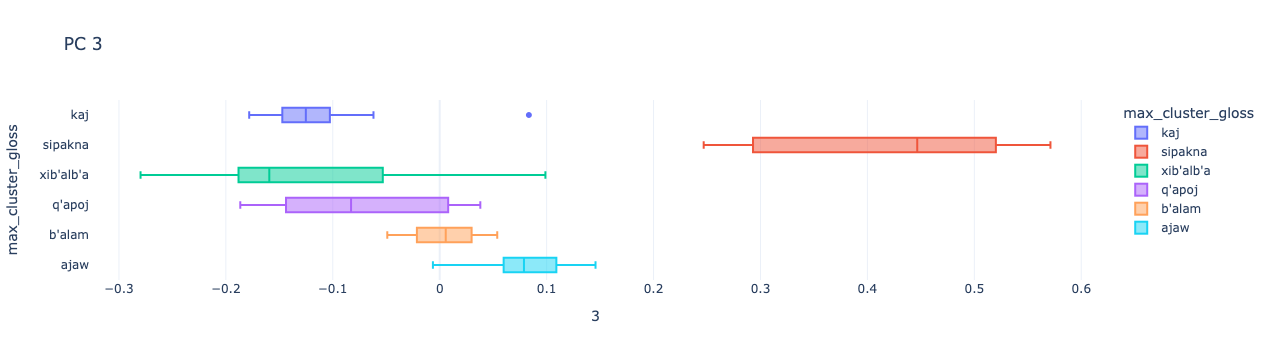

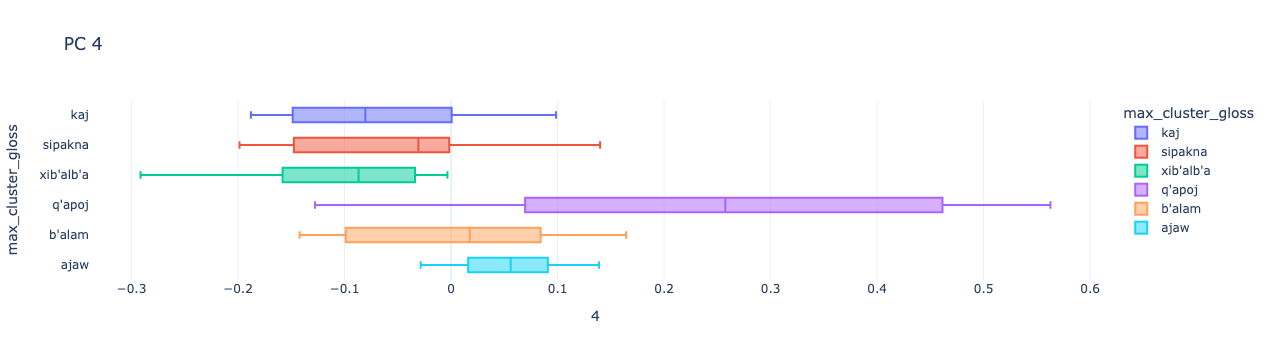

In [4885]:
for i in range(n_comps):
    comp_box(i)

# Topics

## Generate NMF model

Topic modeling with NMF gives further insight into the content of the clusters and how they combine in documents, i.e. units of narrative.

As a form of soft clustering, it lends insight into how each text segment relates to each cluster.

It also corroborates the clustering.

**Choose $k$ based on cluster threshold**

We choose $k$ based on the chosen cut-off threshold for the clustering above.

In [4886]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

Create a list of columns for selection operations.

In [4887]:
k_cols = [i for i in range(k)]
k_cols

[0, 1, 2, 3, 4, 5]

In [4888]:
# NMF?

In [4889]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k, max_iter=10000, 
                 init='nndsvdar', # None, 'random', 'nndsvd', 'nndsvda', 'nndsvdar'
                 # alpha_W=.01,
                 # alpha_H=10,
                 solver='mu', 
                 beta_loss='kullback-leibler'
                )

THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)

PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
PHIX = PHI * np.log2(k/PHI.astype(bool).astype(int).sum())
PHIX = PHI

TOPIC = PHIX.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
TOPIC['gloss'] = PHI.idxmax(1)
TOPIC['gloss2'] = PHIX.idxmax(1)
TOPIC['english'] = TOPIC.gloss.map(VOCAB.gloss)
TOPIC['english2'] = TOPIC.gloss2.map(VOCAB.gloss)

In [4890]:
THETA_SEQ = THETA_SIM.unstack().to_frame('w')
THETA_SEQ.index.names = ['tmp', 'chunk_id']
THETA_SEQ = THETA_SEQ.query("chunk_id == tmp + 1")
THETA_SEQ = THETA_SEQ.reset_index().drop(columns=['tmp']).set_index('chunk_id')
THETA_SEQ['d'] = 1 - THETA_SEQ.w

In [4891]:
# THETA_SEQ.d.plot.bar(figsize=(15,2), rot=0);

In [4892]:
TOPIC

,top_terms,gloss,gloss2,english,english2
topic_id,,,,,
0,"b'alam, amaq', tojil, kitze, majukutaj, k'ab'a...",b'alam,b'alam,jaguar,jaguar
1,"xib'alb'a, kame, junajpu, kik', xcha', b'a, wu...",xib'alb'a,xib'alb'a,underworld (earth),underworld (earth)
2,"ajaw, ja, ajawab', aj, pop, tinamit, nim, k'ic...",ajaw,ajaw,lord,lord
3,"kaj, aj, b'it, winaq, ulew, tz'aq, alom, k'ajo...",kaj,kaj,sky,sky
4,"kaqix, k'ajolab', sipakna, wuqub', jul, kab'ra...",kaqix,kaqix,macaw,macaw
5,"kati't, qati't, ch'o, q'apojib', ati't, chowen...",kati't,kati't,grandmother,grandmother


In [4893]:
CHUNK[f'top_topic_{k}'] = THETA.idxmax(1).values

## Compare topics to clusters

In [4897]:
CHUNK['max_topic'] = THETA.idxmax(1)

In [4898]:
CHUNK[['max_cluster_gloss', 'max_topic']].value_counts().unstack(fill_value=0).style.background_gradient()

max_topic,0,1,2,3,4,5
max_cluster_gloss,,,,,,
ajaw,0,0,8,0,0,0
b'alam,12,0,1,0,0,2
kaj,0,0,0,8,1,0
q'apoj,0,2,0,0,0,6
sipakna,0,0,0,0,6,0
xib'alb'a,0,14,0,0,0,0


In [4902]:
THETA.join(CHUNK[['long_label', 'max_topic']]).style.background_gradient(cmap="YlGnBu", axis=0)

,0,1,2,3,4,5,long_label,max_topic
chunk_id,,,,,,,,
1,0.000000,0.000000,0.000000,0.526282,0.000000,0.000000,[1] 1: Preamble 2: The Primordial World 3: The Creation of the Earth,3
2,0.000000,0.000000,0.000000,0.495315,0.000000,0.000000,[2] 3: The Creation of the Earth 4: The Creation of the Animals 5: The Fall of the Animals,3
3,0.000000,0.000000,0.000000,0.521615,0.000000,0.000000,[3] 5: The Fall of the Animals 6: The Creation of the Mud Person 7: The Creation of the Effigies of Carved Wood,3
4,0.000000,0.000000,0.000000,0.544289,0.000000,0.000000,[4] 7: The Creation of the Effigies of Carved Wood 8: The Fall of the Effigies of Carved Wood,3
5,0.000000,0.000000,0.000000,0.228022,0.310064,0.000000,[5] 8: The Fall of the Effigies of Carved Wood 9: The Pride of Seven Macaw Before the Dawn,4
6,0.000000,0.000000,0.000000,0.000000,0.467782,0.000000,[6] 9: The Pride of Seven Macaw Before the Dawn 10: The Fall of Seven Macaw and His Sons 11: The Defeat of Seven Macaw,4
7,0.000000,0.000000,0.000000,0.000000,0.500403,0.000000,[7] 11: The Defeat of Seven Macaw,4
8,0.000000,0.000000,0.000000,0.000000,0.415446,0.000000,[8] 11: The Defeat of Seven Macaw 12: The Deeds of Zipacna and the Four Hundred Boys,4
9,0.000000,0.000000,0.000000,0.000000,0.468885,0.000000,[9] 12: The Deeds of Zipacna and the Four Hundred Boys 13: The Defeat of Zipacna,4


## View topics over syuzhet: Thematic Structure

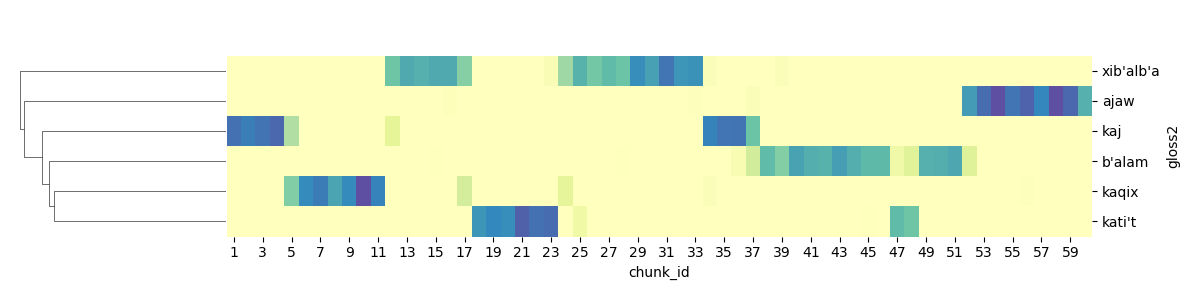

In [4903]:
THETA.columns = TOPIC.gloss2
fig = sns.clustermap(THETA.T, 
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12,3))

## Classify chapters with NMF model

**Model by THETA**

In [4904]:
CHAP_TOPIC_THETA = (
    TOKEN
    .join(THETA, on='chunk_id')[THETA.columns]
    .groupby(['chap_num'])
    .mean()
)

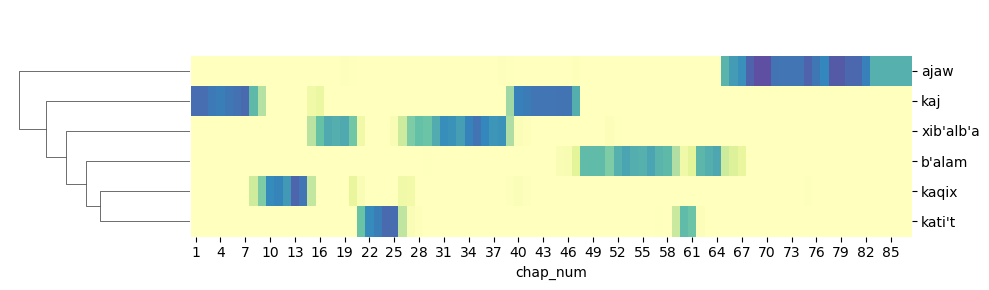

In [4905]:
sns.clustermap(CHAP_TOPIC_THETA.T,
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(10,3));

**Model by PHI**

In [4906]:
CHAP_TOPIC = (
    TOKEN
    .join(PHI.T, on='term_str')
    .dropna()
    .fillna(0)
    .groupby(['chap_num'])[k_cols]
    .mean()
)

# Normalize
CHAP_TOPIC = (CHAP_TOPIC.T/CHAP_TOPIC.T.sum()).T

In [4907]:
# sns.clustermap(CHAP_TOPIC.T.corr(), cmap='YlGnBu', col_cluster=False);

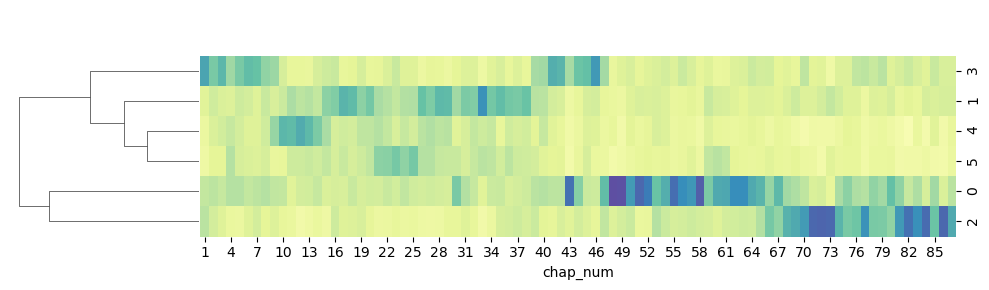

In [4908]:
sns.clustermap(CHAP_TOPIC.T,
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(10,3));

In [4909]:
CHAP['max_topic'] = CHAP_TOPIC[k_cols].idxmax(1)
CHAP['max_topic_theta'] = CHAP_TOPIC_THETA.idxmax(1)
CHAP['max_topic_gloss'] = CHAP.max_topic.map(TOPIC.gloss)

In [4912]:
CHAP[['max_cluster_gloss', 'max_topic_theta']].value_counts().unstack(fill_value=0).style.background_gradient()

max_topic_theta,ajaw,b'alam,kaj,kaqix,kati't,xib'alb'a
max_cluster_gloss,,,,,,
ajaw,21,0,0,0,0,0
b'alam,2,15,1,0,2,1
kaj,0,0,16,1,0,0
q'apoj,0,0,0,0,5,2
sipakna,0,0,0,5,0,0
xib'alb'a,0,0,0,0,1,15


# Sequential correlations

## Sequential Correlations of Chunks

We apply a simplified model of resonance.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Compute color range for centered colormap
z = THETA.T.values
zmin, zmax = z.min(), z.max()
midpoint = 0
vmax = max(abs(zmin - midpoint), abs(zmax - midpoint))
zmin, zmax = midpoint - vmax, midpoint + vmax

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.6, 0.4],
    vertical_spacing=0.1,
    subplot_titles=("Gloss × Chunk Heatmap", "Chunk Distance from Previous")
)

# Heatmap
heatmap = go.Heatmap(
    z=z,
    x=THETA.T.columns,
    y=THETA.T.index,
    colorscale='Spectral',
    zmin=zmin,
    zmax=zmax,
    showscale=False
)
fig.add_trace(heatmap, row=1, col=1)

# Barplot of distances (by similarity)
bar = go.Bar(
    x=THETA_SEQ.index,  # assuming chunk_id is the index
    y=THETA_SEQ['d'],
    marker_color='royalblue'
)
fig.add_trace(bar, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=600,
    width=1000,
    margin=dict(t=60),
    showlegend=False
)

fig.update_annotations(font_size=14)
fig.update_yaxes(title_text="gloss", row=1, col=1)
fig.update_yaxes(title_text="d", row=2, col=1)
fig.update_xaxes(title_text="chunk_id", row=2, col=1)

fig.show()

Evidence for Br and Re break for Part IV -- Midway through Ch. 57.

In [ ]:
CHUNK_CHAP_MATRIX[[52]].dropna().join(CHAP.chap_title)

In [ ]:
CHUNK_CHAP_MATRIX[[38]].dropna().join(CHAP.chap_title)

In [ ]:
CHUNK_CHAP_MATRIX[[34]].dropna().join(CHAP.chap_title)

## Sequential Correlation among Chapters

In [ ]:
CHAP_TOPIC_THETA_SIM = pd.DataFrame(cosine_similarity(CHAP_TOPIC_THETA), index=CHAP_TOPIC_THETA.index, columns=CHAP_TOPIC_THETA.index).stack().to_frame('w')
CHAP_TOPIC_THETA_SIM.index.names = ['tmp', 'chap_id']
CHAP_TOPIC_THETA_SIM = CHAP_TOPIC_THETA_SIM.query("chap_id == tmp + 1").reset_index().set_index('chap_id').drop(columns=['tmp'])
CHAP_TOPIC_THETA_SIM['d'] = 1 - CHAP_TOPIC_THETA_SIM.w
# CHAP_TOPIC_THETA_SIM

In [ ]:
# Compute color range for centered colormap

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.6, 0.4],
    vertical_spacing=0.1,
    subplot_titles=("Glosses over Chpaters", "Chapter Distance from Previous")
)

# Heatmap
z = CHAP_TOPIC_THETA.T.values
zmin, zmax = z.min(), z.max()
midpoint = 0
vmax = max(abs(zmin - midpoint), abs(zmax - midpoint))
zmin, zmax = midpoint - vmax, midpoint + vmax
heatmap = go.Heatmap(
    z=z,
    x=CHAP_TOPIC.T.columns,
    y=TOPIC.gloss, #CHAP_TOPIC.T.index,
    colorscale='Spectral',
    zmin=zmin,
    zmax=zmax,
    showscale=False
)
fig.add_trace(heatmap, row=1, col=1)

# Barplot
X = CHAP_TOPIC_THETA_SIM.join(CHAP).reset_index()
bar = go.Bar(
    x = X.chap_id, 
    y = X.d, #.rolling(2).mean(), 
    marker_color='royalblue'
)
fig.add_trace(bar, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=600,
    width=1000,
    margin=dict(t=60),
    showlegend=False
)

fig.update_annotations(font_size=16)

# fig.update_yaxes(title_text="chapter", row=1, col=1)
fig.update_yaxes(title_text="topic", row=1, col=1)
fig.update_yaxes(title_text="d", row=2, col=1)

fig.update_xaxes(title_text="chapter number", row=2, col=1)

fig.show()

In [ ]:
chap_nums = 8, 9, 10, 15, 16, 21, 26, 27, 39, 40, 48, 65
part_num = 1
for i, chap_num in enumerate(chap_nums):
    if i == 0 or chap_num > chap_nums[i-1] + 1:
        part_num += 1
        print('Part', part_num) #, '-' * 80)
    print("  ", str(chap_num).zfill(2), CHAP.loc[chap_num].chap_title)

In [ ]:
CHAP['wdiff'] = CHAP_TOPIC_THETA_SIM.d
CHAP['new'] = (CHAP_TOPIC_THETA_SIM.d > .25).astype(bool)
CHAP.loc[1, 'new'] = True

# Assign PART titles

In [ ]:
PART = CHAP.loc[CHAP.new == True, ['chap_title']].reset_index()
PART.index.name = 'part_num'
PART = PART.reset_index()
PART.part_num = PART.part_num + 1
PART = PART.set_index('part_num')
PART = PART.sort_index()

In [ ]:
PART

In [ ]:
CHAP['part_num'] = PART.reset_index().set_index('chap_num').part_num
CHAP.part_num = CHAP.part_num.ffill()

In [ ]:
CHAP[['chap_title', 'chunk_ids', 'max_cluster', 'max_topic_theta', 'part_num', 'wdiff', 'new']].style.background_gradient(axis=0)

In [ ]:
CLUSTER

In [ ]:
TOPIC

In [ ]:
PART

# Conclusion

## TOPICS 

- The Parts
  - 7 Parts 
  - Highlighting the role of Blood Woman
  - Optional Preamble and Coda
  - Each part is distinguished temporally and ontologically
- Parts in relation to chronotope
  - Before and after the dawn
  - Above and below the world
  - Transitions: ends adumbrate beginning in the manner of the Haab
- Thematic structure
  - Themes
    - K'aj: Creation
    - B'alam: Religion, Spiritual Authority
    - Ajaw: Rulership, Temporal Power
    - Xib'alb'a: The Underworld, Destruction, Two Boys and their parents
    - Kaqix: 7 Macaw
    - Katoi't: Blood Woman
  - Sequentially
    - Each major part has three parts: Creation, Part A, and Part B
    - The sequence matters: We go from the creation of the world to the creation of society
    - The sequence charts a lineage from the K'iche' kings to the creator gods. 
  - Structurally
    - Two major parts corresponding to before and after the first dawn
    - See PCA
- Entropy
  - The goings on in Xibalba have the moist variability
- General

# Save

In [ ]:
savers = [
    (TFIDF, 'TFIDF'),
    (TFIDF_SIM, 'TFIDF_SIM'),
    (CHAP, 'CHAP_MOD'),
    (CHUNK, 'CHUNK_MOD'),
    (CHUNK_TO_CHAP, 'CHUNK_TO_CHAP'),
    (CHAP_TOPIC, 'CHAP_TOPIC')
]

In [ ]:
for saver in savers:
    obj = saver[0]
    slug = saver[1]
    obj.to_csv(f"christenson-{slug}.csv", index=True)